In [18]:
import csv
import pandas as pd
import numpy as np

from scipy.spatial.transform import Rotation

from datetime import datetime, timezone

import matplotlib.pyplot as plt 


In [19]:
obu_heading_path = '/home/toffanetto/vilma/vilma_ws/src/vilma_tools/vilma_tools/data/imu_yaw_data/rosbag2_driving/obu/heading.csv'

imu_heading_path = '/home/toffanetto/vilma/vilma_ws/src/vilma_tools/vilma_tools/data/imu_yaw_data/rosbag2_driving/filter/euler.csv'

imu_data_path = '/home/toffanetto/vilma/vilma_ws/src/vilma_tools/vilma_tools/data/imu_yaw_data/rosbag2_driving/imu/data.csv'


obu_heading_df = pd.read_csv(obu_heading_path)

imu_heading_df = pd.read_csv(imu_heading_path)

imu_data_df = pd.read_csv(imu_data_path)

In [20]:
imu_data_t = imu_data_df['header_stamp_nsecs'].to_numpy()*1e-9 + imu_data_df['header_stamp_secs'].to_numpy()
obu_heading_t = obu_heading_df['header_stamp_nsecs'].to_numpy()*1e-9 + obu_heading_df['header_stamp_secs'].to_numpy()
imu_heading_t  = imu_heading_df['header_stamp_nsecs'].to_numpy()*1e-9 + imu_heading_df['header_stamp_secs'].to_numpy()


In [21]:
imu_euler_yaw = imu_heading_df[
    [
        "vector_z",
    ]
].to_numpy()

quat_array = imu_data_df[
    [
        "orientation_x",
        "orientation_y",
        "orientation_z",
        "orientation_w",
    ]
].to_numpy()

rotations = Rotation.from_quat(quat_array)

#
imu_data_yaw = rotations.as_euler("xyz", degrees=True)[:,2]

quat_array = obu_heading_df[
    [
        "quaternion_x",
        "quaternion_y",
        "quaternion_z",
        "quaternion_w",
    ]
].to_numpy()

rotations = Rotation.from_quat(quat_array)

obu_heading_yaw = 90 - rotations.as_euler("xyz", degrees=True)[:,2]


In [22]:
idx = np.searchsorted(obu_heading_t, imu_data_t, side='right') - 1
idx = np.clip(idx, 0, len(obu_heading_yaw)-1)

obu_heading_yaw_resampled = obu_heading_yaw[idx]

yaw_offset = obu_heading_yaw_resampled - imu_data_yaw

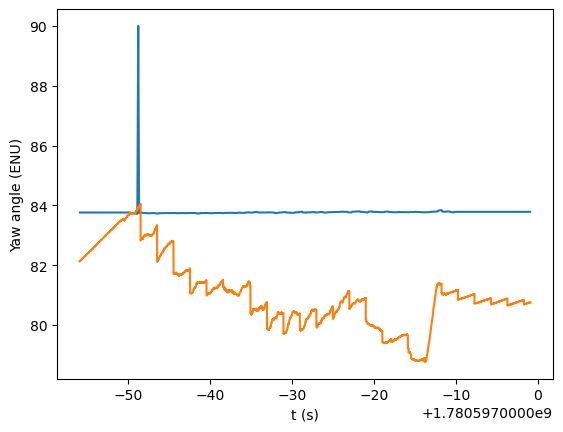

In [23]:
plt.plot(obu_heading_t, obu_heading_yaw, imu_data_t, imu_data_yaw)
plt.ylabel('Yaw angle (ENU)')
plt.xlabel('t (s)')
plt.show()

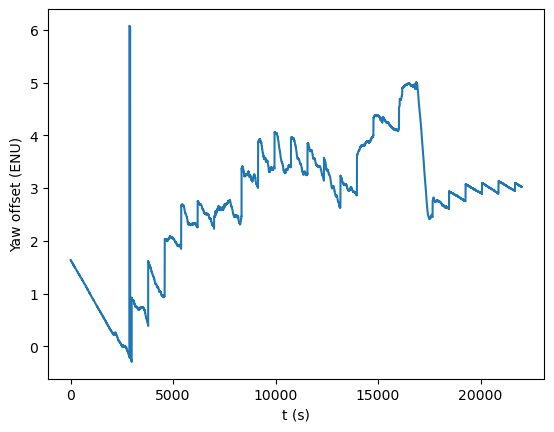

In [24]:
plt.plot(yaw_offset)
plt.ylabel('Yaw offset (ENU)')
plt.xlabel('t (s)')
plt.show()

In [25]:
obu_heading_path = '/home/toffanetto/vilma/vilma_ws/src/vilma_tools/vilma_tools/data/imu_yaw_data/rosbag2_reset_after_drive/obu/heading.csv'

imu_heading_path = '/home/toffanetto/vilma/vilma_ws/src/vilma_tools/vilma_tools/data/imu_yaw_data/rosbag2_reset_after_drive/filter/euler.csv'

imu_data_path = '/home/toffanetto/vilma/vilma_ws/src/vilma_tools/vilma_tools/data/imu_yaw_data/rosbag2_reset_after_drive/imu/data.csv'


obu_heading_df = pd.read_csv(obu_heading_path)

imu_heading_df = pd.read_csv(imu_heading_path)

imu_data_df = pd.read_csv(imu_data_path)

In [26]:
imu_data_t = imu_data_df['header_stamp_nsecs'].to_numpy()*1e-9 + imu_data_df['header_stamp_secs'].to_numpy()
obu_heading_t = obu_heading_df['header_stamp_nsecs'].to_numpy()*1e-9 + obu_heading_df['header_stamp_secs'].to_numpy()
imu_heading_t  = imu_heading_df['header_stamp_nsecs'].to_numpy()*1e-9 + imu_heading_df['header_stamp_secs'].to_numpy()



In [27]:
imu_euler_yaw = imu_heading_df[
    [
        "vector_z",
    ]
].to_numpy()

quat_array = imu_data_df[
    [
        "orientation_x",
        "orientation_y",
        "orientation_z",
        "orientation_w",
    ]
].to_numpy()

rotations = Rotation.from_quat(quat_array)

#
imu_data_yaw = rotations.as_euler("xyz", degrees=True)[:,2]

quat_array = obu_heading_df[
    [
        "quaternion_x",
        "quaternion_y",
        "quaternion_z",
        "quaternion_w",
    ]
].to_numpy()

rotations = Rotation.from_quat(quat_array)

obu_heading_yaw = 90 - rotations.as_euler("xyz", degrees=True)[:,2]


In [28]:
idx = np.searchsorted(obu_heading_t, imu_data_t, side='right') - 1
idx = np.clip(idx, 0, len(obu_heading_yaw)-1)

obu_heading_yaw_resampled = obu_heading_yaw[idx]

yaw_offset = obu_heading_yaw_resampled - imu_data_yaw

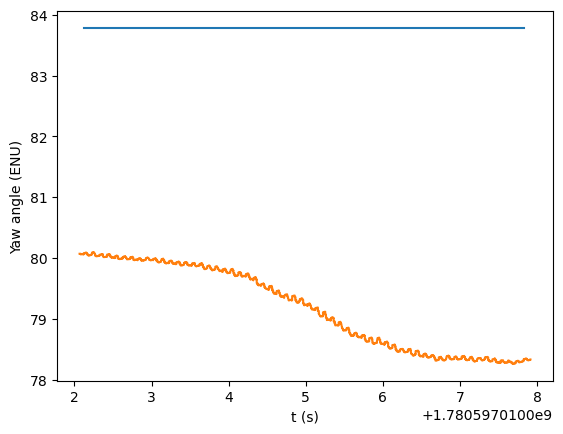

In [29]:
plt.plot(obu_heading_t, obu_heading_yaw, imu_data_t, imu_data_yaw)
plt.ylabel('Yaw angle (ENU)')
plt.xlabel('t (s)')
plt.show()

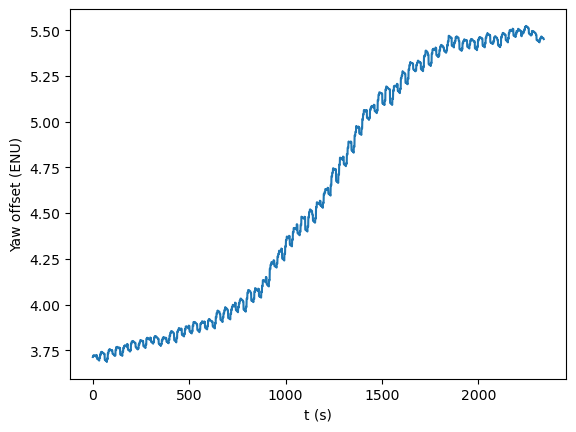

In [30]:
plt.plot(yaw_offset)
plt.ylabel('Yaw offset (ENU)')
plt.xlabel('t (s)')
plt.show()

In [37]:
offset = 3.75/180*np.pi + 0.0684169

print(offset)

0.13386674694978734
